<a href="https://colab.research.google.com/github/Hion-cy/ClassFiles/blob/main/NER_AL263158.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Maestría en Inteligencia Artificial y Analítica de Datos
##Procesamiento del lenguaje natural
**Matrícula:** AL263158

**Alumna:** Carmen Yolanda Hion Vela


###Librerias

In [35]:
import pandas as pd
#!pip install sklearn-crfsuite
import sklearn_crfsuite
from sklearn_crfsuite import metrics
from sklearn_crfsuite import CRF
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

###1.	Carga el conjunto de datos y revisa su contenido.

In [4]:
df = pd.read_csv('/content/drive/MyDrive/NPL/split1.mx-news.txt', sep='\t')
print(df)

          Sentence #         Word    Pos    Tag
0         Sentence 1  Interesante    ADJ      O
1         Sentence 1         será  VLfin      O
2         Sentence 1      conocer  VLinf      O
3         Sentence 1          las    ART      O
4         Sentence 1  reflexiones     NC      O
...              ...          ...    ...    ...
49313  Sentence 1295     edificio     NC      O
49314  Sentence 1295           de   PDEL      O
49315  Sentence 1295           la     NC      O
49316  Sentence 1295  Cancillería   PREP  S-ORG
49317  Sentence 1295            .    ART      O

[49318 rows x 4 columns]


###2.	Preprocesa los datos

para generar las frases tal como las vistas en las diapositivas 19 y 20 de la presentación:
[
 ('Interesante', 'ADJ', 'O'),
 ('será', 'VLfin', 'O'),
 ('conocer', 'VLinf', 'O'),
 ('Pedro', 'NP', 'B-PER'),
 ('Kumamoto', 'NC', 'E-PER')
]


In [16]:
def agrupar_oraciones(df):
    oraciones = []

    grouped = df.groupby("Sentence #")

    for _, grupo in grouped:
        sentence = [(w, p, t) for w, p, t in zip(grupo["Word"], grupo["Pos"], grupo["Tag"])]
        oraciones.append(sentence)

    return oraciones
sentences = agrupar_oraciones(df)

print('Primeras 10 oraciones del texto')
for i in range(10):
    print(f"Oración {i+1}:")
    print(sentences[i])

Primeras 10 oraciones del texto
Oración 1:
[('Interesante', 'ADJ', 'O'), ('será', 'VLfin', 'O'), ('conocer', 'VLinf', 'O'), ('las', 'ART', 'O'), ('reflexiones', 'NC', 'O'), ('de', 'PREP', 'O'), ('Pedro', 'NP', 'B-PER'), ('Kumamoto', 'NC', 'E-PER'), ('en', 'PREP', 'O'), ('torno', 'NC', 'O'), ('a', 'PREP', 'O'), ('este', 'DM', 'O'), ('fracaso', 'NC', 'O'), (',', 'CM', 'O'), ('por', 'PREP', 'O'), ('el', 'ART', 'O'), ('momento', 'NC', 'O'), ('lo', 'ART', 'O'), ('único', 'NC', 'O'), ('que', 'CQUE', 'O'), ('ha', 'VHfin', 'O'), ('dicho', 'QU', 'O'), ('es', 'VSfin', 'O'), ('que', 'CQUE', 'O'), ('al', 'PAL', 'O'), ('interior', 'NC', 'O'), ('de', 'PREP', 'O'), ('su', 'PPO', 'O'), ('grupo', 'NC', 'O'), ('existen', 'VLfin', 'O'), ('dos', 'CARD', 'O'), ('planteamientos', 'NC', 'O'), (',', 'CM', 'O'), ('uno', 'CARD', 'O'), ('seguir', 'VLinf', 'O'), ('por', 'PREP', 'O'), ('la', 'ART', 'O'), ('ruta', 'NC', 'O'), ('independiente', 'ADJ', 'O'), (',', 'CM', 'O'), ('el', 'ART', 'O'), ('otro', 'QU', 'O'), 

###3.	Genera el conjunto train
con el 80% de las frases formadas y el 20% para el conjunto test.

In [29]:
def word2features(sent, i):
    word = sent[i][0]
    postag = sent[i][1]
    features = {
        'bias': 1.0,
        'word.lower()': word.lower(),
        'word.istitle()': word.istitle(),
        'word.isupper()': word.isupper(),
        'postag': postag,
    }
    return features

def sent2features(sent): return [word2features(sent, i) for i in range(len(sent))]
def sent2labels(sent): return [label for token, postag, label in sent]

X = [sent2features(s) for s in sentences]
y = [sent2labels(s) for s in sentences]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("--- Evidencia de División de Datos ---")
print(f"Total de oraciones en el dataset: {len(X)}")
print(f"Oraciones para Entrenamiento (80%): {len(X_train)}")
print(f"Oraciones para Pruebas (20%): {len(X_test)}")

crf = CRF(algorithm='lbfgs', c1=0.1, c2=0.1, max_iterations=100, all_possible_transitions=True)
crf.fit(X_train, y_train)

print("\nEjemplo la primera palabra en entrenamiento")
print(X_train[0][0])

--- Evidencia de División de Datos ---
Total de oraciones en el dataset: 1295
Oraciones para Entrenamiento (80%): 1036
Oraciones para Pruebas (20%): 259

Ejemplo la primera palabra en entrenamiento
{'bias': 1.0, 'word.lower()': 'consideró', 'word.istitle()': True, 'word.isupper()': False, 'postag': 'VLfin'}


###4.	Aplica las métricas para evaluar el desempeño del modelo.

In [41]:
y_pred = crf.predict(X_test)
print(metrics.flat_classification_report(y_test, y_pred, digits=3))

y_test_flat = [item for sublist in y_test for item in sublist]
y_pred_flat = [item for sublist in y_pred for item in sublist]
labels = list(crf.classes_)


              precision    recall  f1-score   support

       B-ADD      0.889     0.727     0.800        11
       B-AGE      0.889     1.000     0.941         8
       B-DAT      0.929     0.859     0.893        92
       B-DOC      0.833     0.294     0.435        17
       B-EVT      0.750     0.529     0.621        17
       B-FAC      1.000     0.545     0.706        11
       B-GPE      0.931     0.818     0.871        33
       B-LOC      1.000     0.500     0.667         2
       B-MNY      1.000     0.917     0.957        12
       B-ORG      0.839     0.830     0.834        88
       B-PER      0.871     0.928     0.899       153
       B-PEX      1.000     0.714     0.833        14
       B-PRC      1.000     1.000     1.000         5
       B-PRO      0.667     0.444     0.533         9
       B-TIM      1.000     0.826     0.905        23
       B-TIT      0.857     0.667     0.750        63
       E-ADD      0.889     0.727     0.800        11
       E-AGE      0.889    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


###5.	Muestra la matriz de confusión.

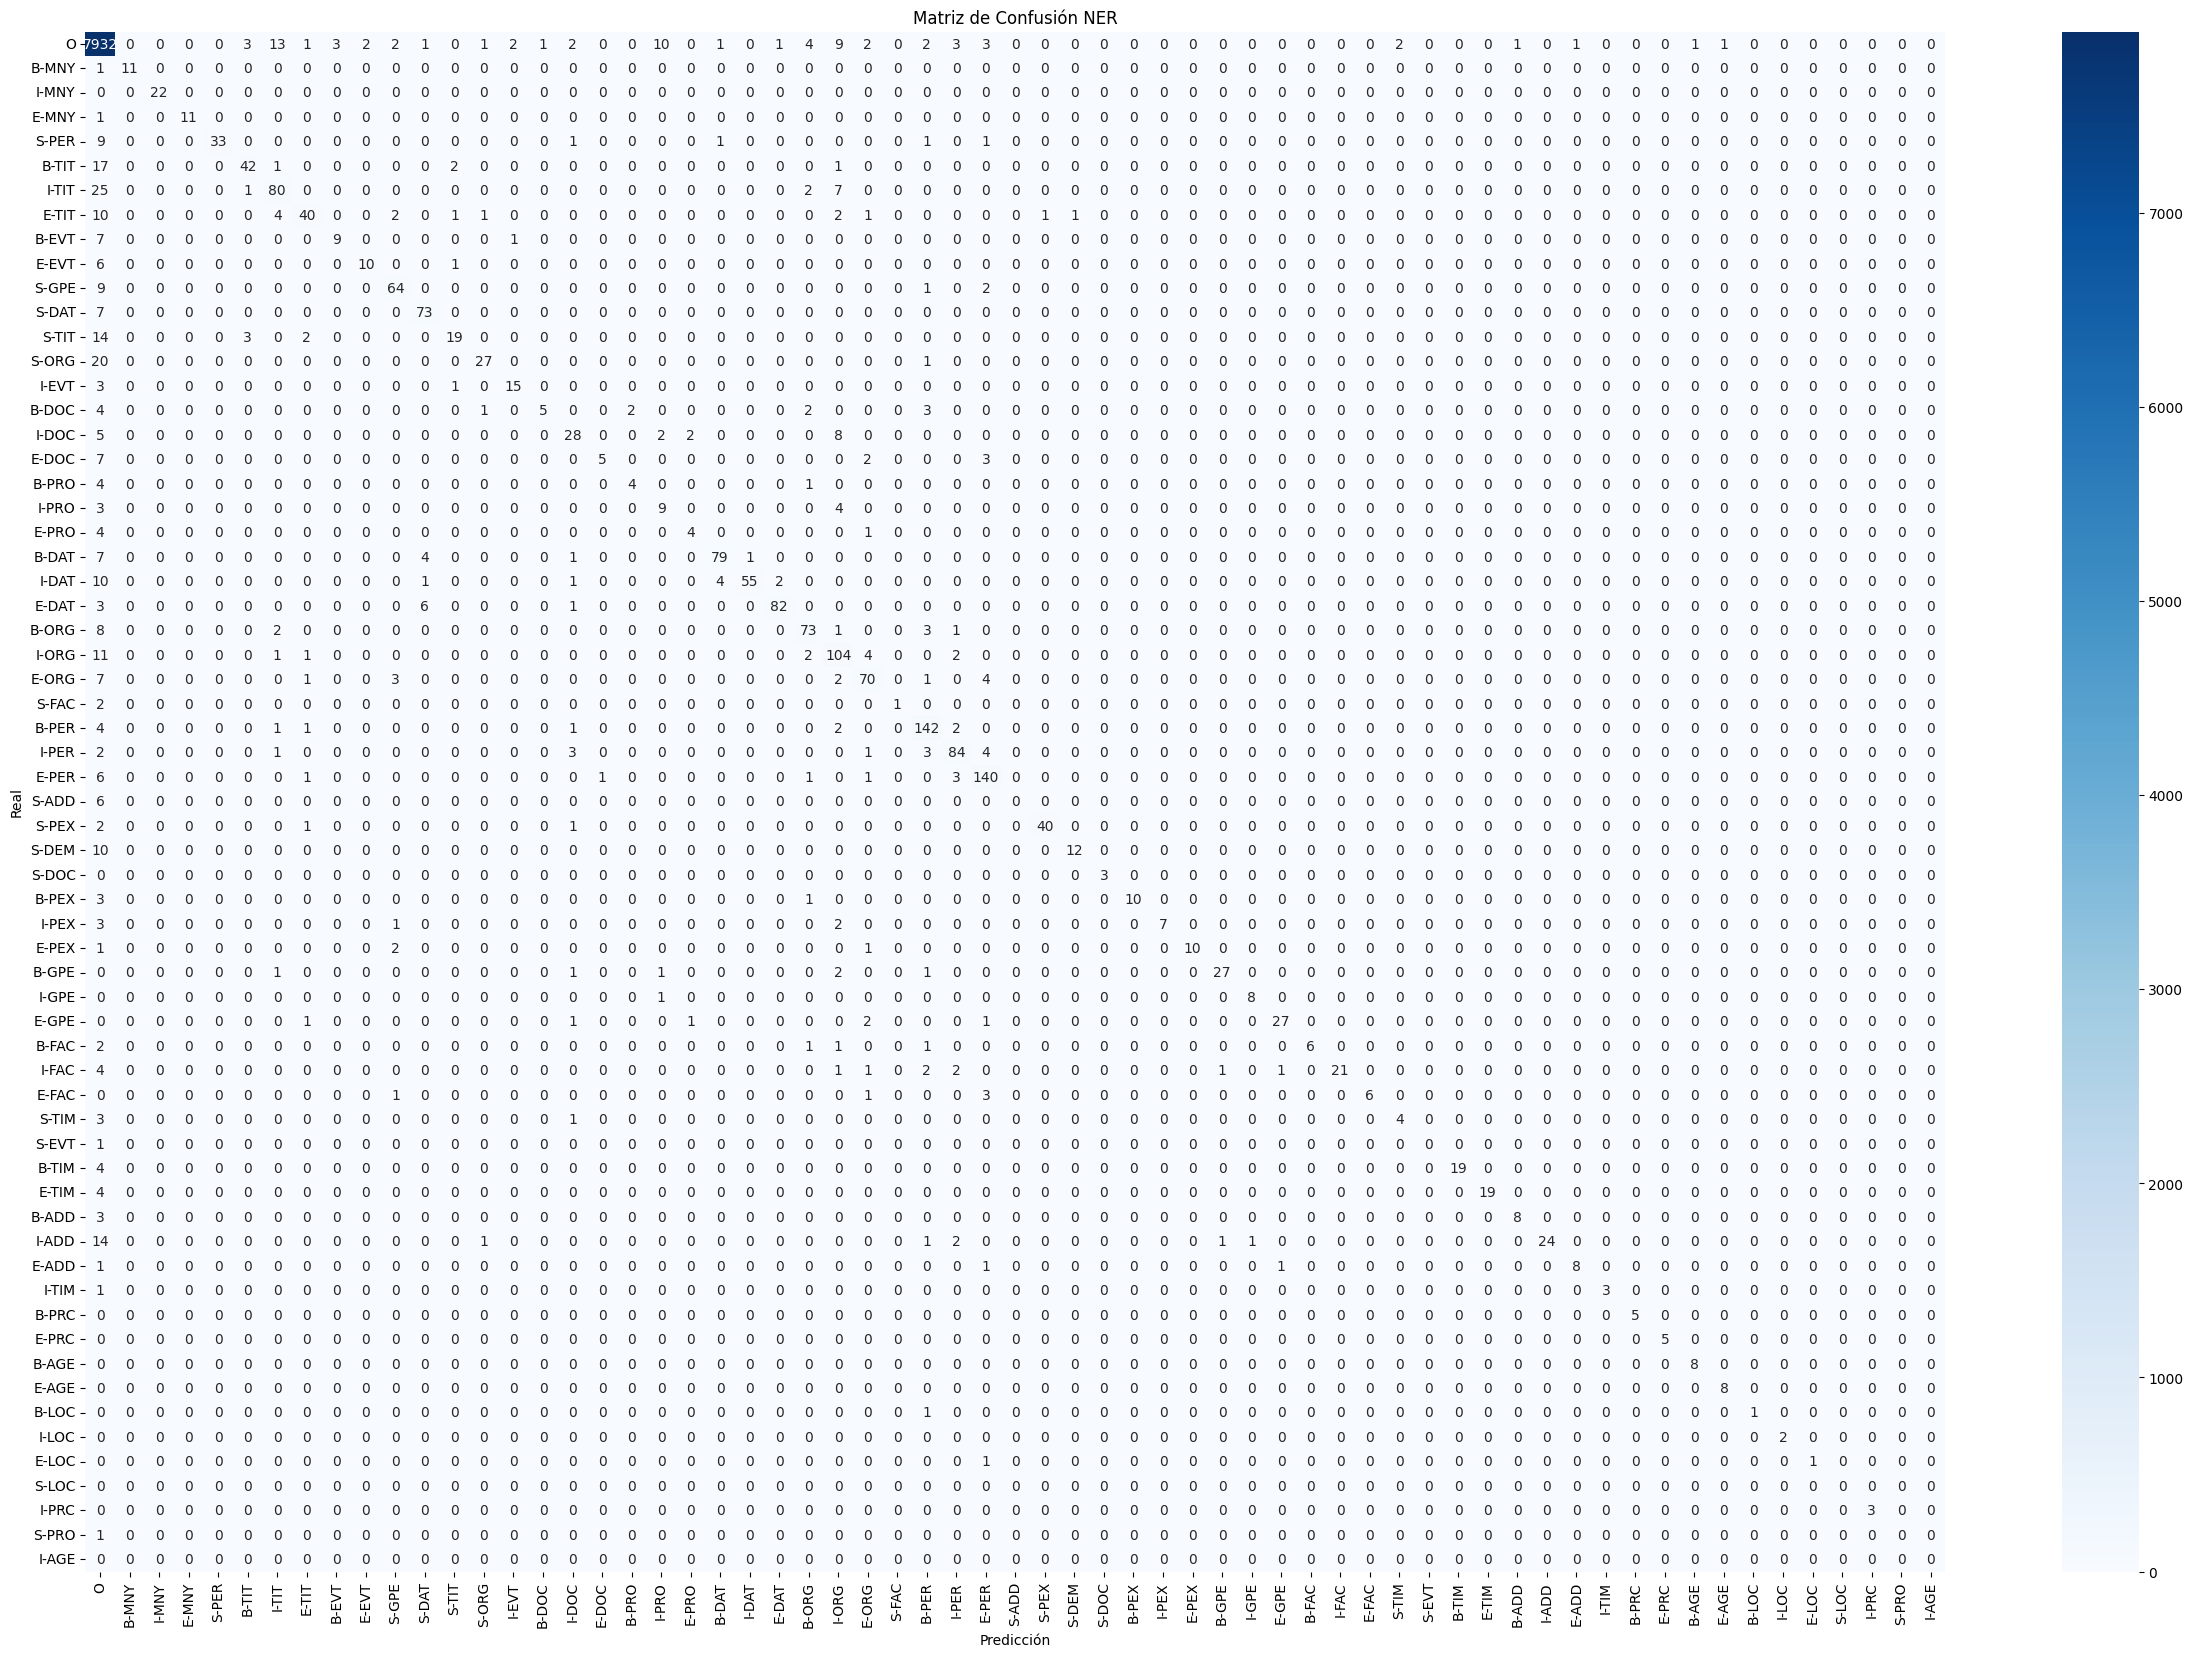

In [39]:
cm = confusion_matrix(y_test_flat, y_pred_flat, labels=labels)

plt.figure(figsize=(30,20))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión NER')
plt.show()

###6.	Identifica y menciona cuál fue la etiqueta NER que consideres fue en la que CRF tuvo el más bajo desempeño.

Las etiquetas con el peor desempeño son S-ADD, S-EVT y S-PRO con un porcentaje de 0 en F1 score
| Etiqueta | Precisión | Recall | F1-score | Soporte |
| :--- | :---: | :---: | :---: | :---: |
| **S-ADD** | 0.000 | 0.000 | 0.000 | 6 |
| **S-EVT** | 0.000 | 0.000 | 0.000 | 1 |
| **S-PRO** | 0.000 | 0.000 | 0.000 | 1 |

Si consideramos las demas etiquetas el valor de support (entre 6 y 1) se evidencia que el modelo no cuenta con datos suficientes datos para identificar los patrones.

